In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
from pathlib import Path

In [21]:
YEAR = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{YEAR}')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
0,0.133333,0.133333,0.121569,0.141176,0.007843,0.133333,0.109804,0.145098,0.019608,0.12549,...,NOT_VEGETATED,0.03115,0.218391,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667


# Train:test:split

In [4]:
# Decide on which region to train for
REGION = 'Ashanti'
region_mask = raw_Xy.region == REGION

# Figure out which folds are for train/val and which for test
test_size = 0.2
region_fold_idxs = metadata_df[region_mask].fold_idx.unique()
n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")

# Split
Xy_train = raw_Xy[~test_mask]
metadata_df_train = metadata_df[~test_mask]
Xy_test = raw_Xy[test_mask]
metadata_df_test = metadata_df[test_mask]

10/50 regions for testing (4811 points)


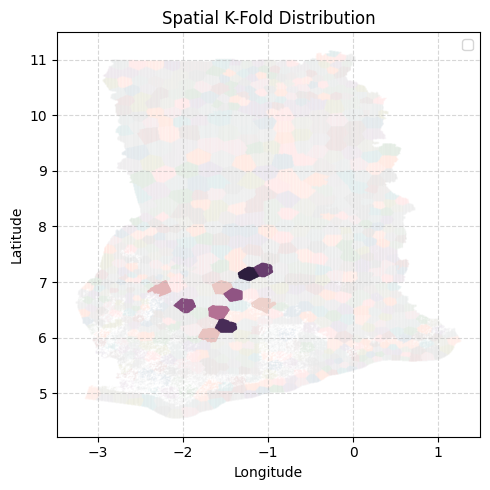

In [5]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=metadata_df[~test_mask], x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=metadata_df[test_mask], x='lon', y='lat', hue='fold_idx', color='r', s=1, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train models

In [6]:
# Build X,y
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train > 0.65)
yhat_test = dummy_clf.predict(X_test)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.4095
Baseline Macro Precision: 0.5030
Baseline Macro Recall: 0.5044
- Negative (0)
- F1: 0.3094
-- Precision: 0.2045
-- Recall: 0.6351
- Positive (1)
- F1: 0.5097
-- Precision: 0.8016
-- Recall: 0.3736


# Prep hyperparam optimization

In [7]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_validate, GroupKFold

def optuna_objective_factory(X, y, groups, always_train_mask):
    """
    always_train_mask: A boolean list/array of the same length as X. 
                       True means the sample is always used in training.
                       False means the sample is rotated via GroupKFold.
    """
    
    # --- 1. Pre-calculate the custom CV splits once ---
    always_train_mask = np.array(always_train_mask)
    
    # Get absolute indices for both groups
    fixed_indices = np.where(always_train_mask)[0]
    rot_indices = np.where(~always_train_mask)[0]
    
    # Extract just the groups for the rotating portion
    groups_rot = np.array(groups)[rot_indices]
    
    # GroupKFold only needs the shape and the groups, so we can use a dummy array
    dummy_X_rot = np.zeros(len(rot_indices))
    
    gkf = GroupKFold(n_splits=5)
    custom_cv = []
    
    # Generate the splits only on the rotating data
    for train_idx_rel, val_idx_rel in gkf.split(dummy_X_rot, dummy_X_rot, groups_rot):
        
        # Map the relative fold indices back to the absolute indices of the full dataset
        train_idx_rot = rot_indices[train_idx_rel]
        val_idx_rot = rot_indices[val_idx_rel]
        
        # Combine the fixed indices with the rotating training fold
        full_train_idx = np.concatenate([fixed_indices, train_idx_rot])
        
        # Append the (train, validation) tuple scikit-learn expects
        custom_cv.append((full_train_idx, val_idx_rot))

    # Pre-calculate the validation sizes for each fold
    val_sizes = [len(val_idx) for _, val_idx in custom_cv]

    # --- 2. The Objective Function ---
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        model = lgb.LGBMClassifier(**param)
        
        # Pass the pre-computed custom_cv list to the cv parameter
        scores = cross_validate(
            model, X, y, 
            cv=custom_cv, 
            scoring=['f1', 'precision', 'recall'], 
            n_jobs=1
        )
        
        trial.set_user_attr('f1s', scores["test_f1"])
        trial.set_user_attr('precisions', scores["test_precision"])
        trial.set_user_attr('recalls', scores["test_recall"])
        
        # Add the validation set sizes to the trial attributes
        trial.set_user_attr('val_sizes', val_sizes)
        
        return np.median(scores['test_f1'])

    return objective

# Train dummy LGBM baseline

In [8]:
def get_dummy_feature(X):
    features = ["valid_observations"]
    return X[features]
    
# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_dummy_feature(X_train)
X_test = get_dummy_feature(X_test)

X_train.head(1)

,valid_observations
0,7


In [9]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, always_train_mask, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, always_train_mask), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, yhat_train, yhat_test, study.best_trial.user_attrs

_, _, _, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:46:26,716] A new study created in memory with name: no-name-7abe4df4-f951-40c1-978f-32a70c1f433a


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:46:31,328] Trial 0 finished with value: 0.7529093369418133 and parameters: {'n_estimators': 463, 'learning_rate': 0.010809430562506094, 'max_depth': 6, 'num_leaves': 242, 'subsample': 0.7219625612384903, 'colsample_bytree': 0.7297897854476698, 'min_child_samples': 92}. Best is trial 0 with value: 0.7529093369418133.
[I 2026-06-22 11:46:34,202] Trial 1 finished with value: 0.7529093369418133 and parameters: {'n_estimators': 322, 'learning_rate': 0.014673487045185157, 'max_depth': 2, 'num_leaves': 87, 'subsample': 0.582160968730515, 'colsample_bytree': 0.5870810429521642, 'min_child_samples': 78}. Best is trial 0 with value: 0.7529093369418133.
[I 2026-06-22 11:46:41,720] Trial 2 finished with value: 0.7529093369418133 and parameters: {'n_estimators': 302, 'learning_rate': 0.17625755954202202, 'max_depth': 15, 'num_leaves': 48, 'subsample': 0.7499582038543016, 'colsample_bytree': 0.9152004269313274, 'min_child_samples': 76}. Best is trial 0 with value: 0.7529093369418133

# Train LGBM baseline

In [10]:
# Baseline LGBM
def get_base_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_features(X_train)
X_test = get_base_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608


In [11]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:46:55,765] A new study created in memory with name: no-name-943e7f99-c8fa-41a5-93ce-ae01f8adba4a


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:47:14,287] Trial 0 finished with value: 0.8749505342303127 and parameters: {'n_estimators': 476, 'learning_rate': 0.030678901611831972, 'max_depth': 10, 'num_leaves': 79, 'subsample': 0.8277450566857527, 'colsample_bytree': 0.9067904380052114, 'min_child_samples': 82}. Best is trial 0 with value: 0.8749505342303127.
[I 2026-06-22 11:47:20,563] Trial 1 finished with value: 0.8736862978385881 and parameters: {'n_estimators': 398, 'learning_rate': 0.09820324746271308, 'max_depth': 3, 'num_leaves': 250, 'subsample': 0.675984377329153, 'colsample_bytree': 0.7905107436009029, 'min_child_samples': 26}. Best is trial 0 with value: 0.8749505342303127.
[I 2026-06-22 11:47:34,561] Trial 2 finished with value: 0.8739829331216511 and parameters: {'n_estimators': 268, 'learning_rate': 0.054637195572745184, 'max_depth': 8, 'num_leaves': 105, 'subsample': 0.933154990405396, 'colsample_bytree': 0.6890654711637789, 'min_child_samples': 39}. Best is trial 0 with value: 0.8749505342303127

# Consider the SCL and region

In [12]:
# Take into account this SCL
def get_base_and_scl_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_features(X_train)
X_test = get_base_and_scl_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl,region
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608,NOT_VEGETATED,Upper East


In [13]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:47:40,224] A new study created in memory with name: no-name-749fa343-7981-4fb7-a801-3e9e46498d88


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:47:43,902] Trial 0 finished with value: 0.8735949516860579 and parameters: {'n_estimators': 128, 'learning_rate': 0.07128388545429368, 'max_depth': 5, 'num_leaves': 182, 'subsample': 0.6451242007569429, 'colsample_bytree': 0.5840514960440216, 'min_child_samples': 74}. Best is trial 0 with value: 0.8735949516860579.
[I 2026-06-22 11:47:52,764] Trial 1 finished with value: 0.874329958308517 and parameters: {'n_estimators': 218, 'learning_rate': 0.09039216723004148, 'max_depth': 7, 'num_leaves': 148, 'subsample': 0.5001925091677457, 'colsample_bytree': 0.6722726664735377, 'min_child_samples': 95}. Best is trial 1 with value: 0.874329958308517.
[I 2026-06-22 11:48:02,123] Trial 2 finished with value: 0.8744038155802861 and parameters: {'n_estimators': 130, 'learning_rate': 0.050174619537559355, 'max_depth': 10, 'num_leaves': 131, 'subsample': 0.9405595731776701, 'colsample_bytree': 0.9003555793135549, 'min_child_samples': 80}. Best is trial 2 with value: 0.8744038155802861

# Add TCI & other features

In [14]:
# Take into account this SCL
def get_base_and_scl_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_advanced_features(X_train)
X_test = get_base_and_scl_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,region,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608,...,Upper East,0.03115,0.218391,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667


In [15]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:48:04,596] A new study created in memory with name: no-name-94ad8e38-e7e3-4a18-96e9-34eaf9810f24


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:48:15,566] Trial 0 finished with value: 0.866864490603363 and parameters: {'n_estimators': 484, 'learning_rate': 0.010096787704171346, 'max_depth': 3, 'num_leaves': 76, 'subsample': 0.825785485920118, 'colsample_bytree': 0.6195147874331668, 'min_child_samples': 82}. Best is trial 0 with value: 0.866864490603363.
[I 2026-06-22 11:48:41,156] Trial 1 finished with value: 0.8734987990392313 and parameters: {'n_estimators': 475, 'learning_rate': 0.022548302013523185, 'max_depth': 7, 'num_leaves': 99, 'subsample': 0.8890725211745794, 'colsample_bytree': 0.7723789574473257, 'min_child_samples': 61}. Best is trial 1 with value: 0.8734987990392313.
[I 2026-06-22 11:48:59,593] Trial 2 finished with value: 0.8734530938123752 and parameters: {'n_estimators': 410, 'learning_rate': 0.055427523361468965, 'max_depth': 7, 'num_leaves': 235, 'subsample': 0.6147202421958096, 'colsample_bytree': 0.6311180259515007, 'min_child_samples': 98}. Best is trial 1 with value: 0.8734987990392313.


# Keep track of #valid observations

In [16]:
# Take into account this SCL
def get_base_and_scl_and_obs_cnt_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608,...,0.03115,0.218391,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667,7


In [17]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:49:06,452] A new study created in memory with name: no-name-6d434fd5-78a4-4b64-892a-7674d830667c


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:49:29,760] Trial 0 finished with value: 0.8759595959595959 and parameters: {'n_estimators': 373, 'learning_rate': 0.010326645795443425, 'max_depth': 8, 'num_leaves': 79, 'subsample': 0.6764891239285336, 'colsample_bytree': 0.7103167816177118, 'min_child_samples': 75}. Best is trial 0 with value: 0.8759595959595959.
[I 2026-06-22 11:49:34,381] Trial 1 finished with value: 0.8673189823874755 and parameters: {'n_estimators': 252, 'learning_rate': 0.05039106928692544, 'max_depth': 2, 'num_leaves': 234, 'subsample': 0.7242089188087772, 'colsample_bytree': 0.6483968837097468, 'min_child_samples': 27}. Best is trial 0 with value: 0.8759595959595959.
[I 2026-06-22 11:49:47,353] Trial 2 finished with value: 0.8776167471819646 and parameters: {'n_estimators': 197, 'learning_rate': 0.0371735808068347, 'max_depth': 7, 'num_leaves': 199, 'subsample': 0.5455645932105777, 'colsample_bytree': 0.5108107412421159, 'min_child_samples': 65}. Best is trial 2 with value: 0.8776167471819646.

# Keep track of cloud confidence

In [18]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence
0,0.066667,0.094118,0.133333,0.176471,0.192157,0.203922,0.207843,0.207843,0.262745,0.219608,...,0.218391,0.074277,-0.116667,0.081633,0.039216,0.009524,0.12192,-0.116667,7,0


In [19]:
clf, yhat_train, yhat_test, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-22 11:49:50,491] A new study created in memory with name: no-name-d4ec7242-e08e-4efa-b186-9340b2dc29c4


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-22 11:50:03,052] Trial 0 finished with value: 0.8698869475847893 and parameters: {'n_estimators': 118, 'learning_rate': 0.011878301018767282, 'max_depth': 14, 'num_leaves': 136, 'subsample': 0.7480665995199967, 'colsample_bytree': 0.7501083926799545, 'min_child_samples': 41}. Best is trial 0 with value: 0.8698869475847893.
[I 2026-06-22 11:51:07,135] Trial 1 finished with value: 0.8775387090287553 and parameters: {'n_estimators': 460, 'learning_rate': 0.011663540386720376, 'max_depth': 12, 'num_leaves': 219, 'subsample': 0.9345876377402429, 'colsample_bytree': 0.5690472293109498, 'min_child_samples': 95}. Best is trial 1 with value: 0.8775387090287553.
[I 2026-06-22 11:51:32,052] Trial 2 finished with value: 0.8756539235412475 and parameters: {'n_estimators': 216, 'learning_rate': 0.06414497651969792, 'max_depth': 12, 'num_leaves': 230, 'subsample': 0.5411688959873848, 'colsample_bytree': 0.5110152625443007, 'min_child_samples': 29}. Best is trial 1 with value: 0.87753870902

# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?